<a href="https://colab.research.google.com/github/anhndt0310-jpg/Cyberbullying-Detection-MultiClass/blob/main/Cyberbullying_Detection_MultiClass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Kết nối với Google Drive
drive.mount('/content/drive')

# 2. Đọc file dữ liệu (Em nhớ sửa đường dẫn đúng với nơi em lưu file trên Drive nhé)
path = "/content/drive/MyDrive/cyberbullying_tweets.csv"
df = pd.read_csv(path)

# 3. Xem thử 5 dòng đầu tiên
print("Dữ liệu mẫu:")
display(df.head())

Mounted at /content/drive
Dữ liệu mẫu:


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [8]:
# 4. Kiểm tra số lượng tin nhắn trong từng loại bắt nạt
print("\nSố lượng mẫu trong mỗi lớp:")
print(df['cyberbullying_type'].value_counts())

# 5. Kiểm tra xem có dữ liệu trống (null) không
print("\nKiểm tra dữ liệu trống:")
print(df.isnull().sum())


Số lượng mẫu trong mỗi lớp:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

Kiểm tra dữ liệu trống:
tweet_text            0
cyberbullying_type    0
dtype: int64


Vì máy tính chỉ hiểu số (Chapter 6), em cần biến các câu tweet thành một ma trận số bằng kỹ thuật TF-IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Khởi tạo bộ biến đổi chữ thành số
tfidf = TfidfVectorizer(max_features=5000) # Lấy 5000 từ phổ biến nhất

# Biến đổi cột văn bản thành ma trận số X
X = tfidf.fit_transform(df['tweet_text'])
y = df['cyberbullying_type']

print(f"Kích thước ma trận đặc trưng X: {X.shape}")

Kích thước ma trận đặc trưng X: (47692, 5000)


Theo giáo trình, em nên chia dữ liệu thành các tập Train, Validation, và Test để tránh Overfitting (Học thuộc lòng nhiễu)

In [10]:
from sklearn.model_selection import train_test_split

# Chia làm 2 bước để lấy 3 tập theo tỷ lệ 60/20/20
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Số lượng mẫu tập Train: {X_train.shape}")
print(f"Số lượng mẫu tập Val: {X_val.shape}")
print(f"Số lượng mẫu tập Test: {X_test.shape}")

Số lượng mẫu tập Train: (28615, 5000)
Số lượng mẫu tập Val: (9538, 5000)
Số lượng mẫu tập Test: (9539, 5000)


Vì bài toán của em là phân loại văn bản đa lớp (Multi-class), anh gợi ý em dùng Multinomial Naïve Bayes (Chapter 6
) làm baseline vì nó rất nhanh và hiệu quả với dữ liệu văn bản. Sau đó, em thử thêm Random Forest (mở rộng của Cây quyết định - Chapter 7
) để so sánh kết quả.


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# 1. Huấn luyện Naïve Bayes (Chapter 6)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 2. Huấn luyện Random Forest (Dựa trên kiến thức Chapter 7)
# Anh thêm class_weight='balanced' để mô hình chú ý hơn các lớp ít mẫu, giúp tăng Recall
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("Đã huấn luyện xong 2 mô hình!")

Đã huấn luyện xong 2 mô hình!


Đây là bước để em trả lời câu hỏi của thầy. Chúng ta sẽ dùng Ma trận nhầm lẫn (Confusion Matrix) để xem mô hình đang bị nhầm nhãn "bắt nạt" nào sang nhãn "lành mạnh"
.

Báo cáo phân loại (Random Forest):
                     precision    recall  f1-score   support

                age       0.96      0.98      0.97      1555
          ethnicity       0.99      0.98      0.98      1638
             gender       0.91      0.81      0.86      1592
  not_cyberbullying       0.60      0.48      0.53      1642
other_cyberbullying       0.53      0.69      0.60      1528
           religion       0.94      0.95      0.95      1583

           accuracy                           0.82      9538
          macro avg       0.82      0.82      0.82      9538
       weighted avg       0.82      0.82      0.82      9538



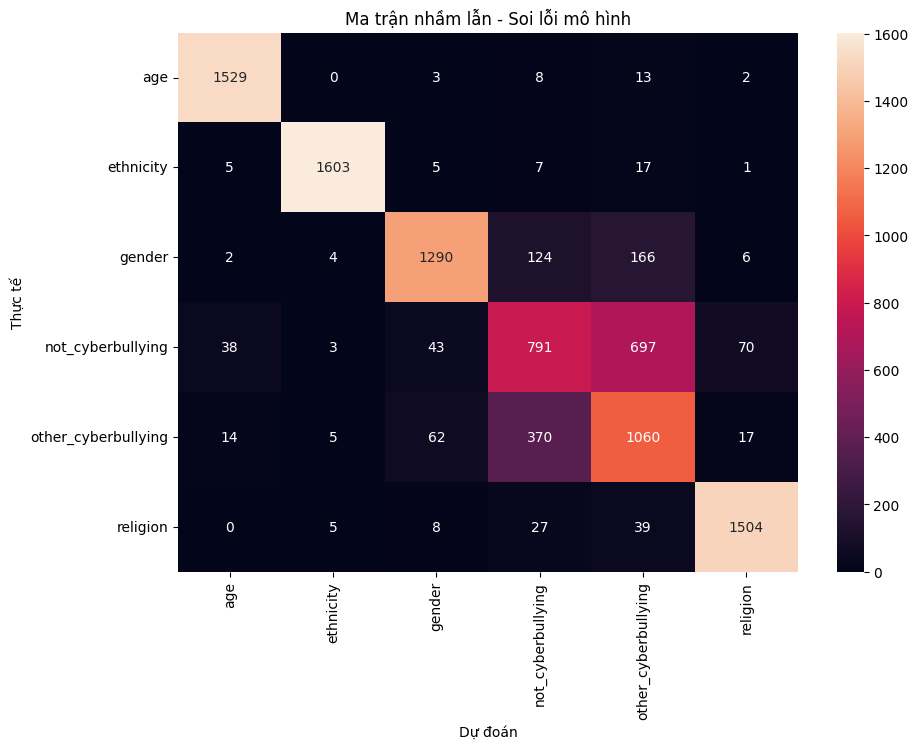

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Dự đoán trên tập Validation
y_pred = rf_model.predict(X_val)

# in báo cáo chi tiết các chỉ số Precision, Recall, F1-score
print("Báo cáo phân loại (Random Forest):")
print(classification_report(y_val, y_pred))

# Vẽ Ma trận nhầm lẫn để giải trình với thầy (Chapter 5)
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Ma trận nhầm lẫn - Soi lỗi mô hình')
plt.show()

Nếu Recall vẫn thấp (tức là mô hình "nhút nhát", bỏ sót nhiều vụ bắt nạt
), em hãy dùng kỹ thuật Hạ ngưỡng quyết định (Threshold Tuning). Thay vì để máy tự quyết định ở mức 0.5, em có thể hạ xuống để máy "nhạy cảm" hơn với các dấu hiệu bắt nạt
.
Lưu ý: Với bài toán đa lớp, việc chỉnh ngưỡng sẽ phức tạp hơn một chút bằng cách can thiệp vào xác suất của từng lớp (predict_proba).